In [24]:
%pylab inline

import pandas as p
from scipy.cluster.hierarchy import average, dendrogram
from scipy.spatial.distance import pdist, euclidean
from scipy.cluster import hierarchy as hc
from numpy import isnan, nan
from matplotlib.colors import Normalize, LinearSegmentedColormap

Populating the interactive namespace from numpy and matplotlib


/home/matej/Programs/anaconda3/envs/thecellmap/lib/python3.6/site-packages/IPython/core/magics/pylab.py:160: UserWarning: pylab import has clobbered these variables: ['average']
`%matplotlib` prevents importing * from pylab and numpy
  "\n`%matplotlib` prevents importing * from pylab and numpy"


In [25]:
rcParams.update({'font.size': 6})

In [26]:
def heat_color():
    return {'red': ((0.0, 1.0, 1.0),
                 (0.5, 0.0, 0.0),
                 (1.0, 0.0, 0.0)),
         'green': ((0.0, 0.0, 0.0),
                   (0.5, 0.0, 0.0),
                   (1.0, 1.0, 1.0)),
         'blue': ((0.0, 0.0, 0.0),
                  (0.5, 0.0, 0.0),
                  (1.0, 0.0, 0.0))}
CMAP = LinearSegmentedColormap('my_colormap',heat_color(),256)

In [27]:
merged = p.read_csv('/home/matej/pbrtest.csv', index_col=0).dropna(thresh=2)

In [28]:
merged.shape[0]

1326

In [29]:
# merged.index = [' - '.join(i) for i in merged.index]
denmat = merged.fillna(0)

In [40]:
array_den = dendrogram(average(pdist(denmat, metric='correlation')), no_plot=True)
query_den = dendrogram(average(pdist(denmat.T, metric='correlation')), no_plot=True)

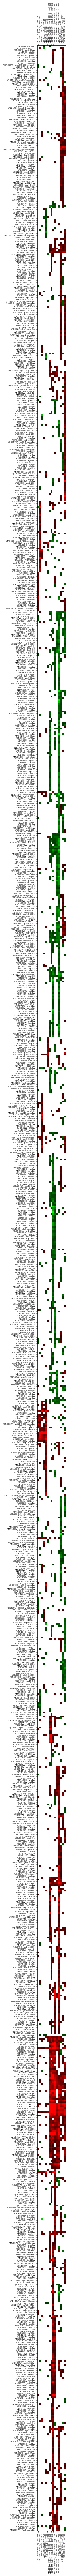

In [41]:
df = merged.iloc[array_den['leaves'], query_den['leaves']]
imshow(df, vmin=-.5, vmax=.5, interpolation='nearest', cmap=CMAP)
gcf().set_size_inches((5, (df.shape[0] / 10) + 2))
_ = yticks(arange(df.shape[0]), df.index)
_ = xticks(arange(df.shape[1]), df.columns, rotation='vertical')
tick_params(axis='x', labeltop=True, labelbottom=True, top=True, bottom=True)

savefig('/home/matej/figure5.pdf', dpi=100, bbox_inches='tight')